In [12]:
import pandas as pd

df = pd.read_csv('../data/raw/vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


In [14]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [15]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [16]:
df_clean = df.dropna()
df_clean.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [17]:
len(df_clean)

16291

In [18]:
df_clean.to_csv('../data/processed/vgsales_clean.csv', index=False)

In [19]:
import os
os.listdir('../data/processed')

['vgsales_clean.csv']

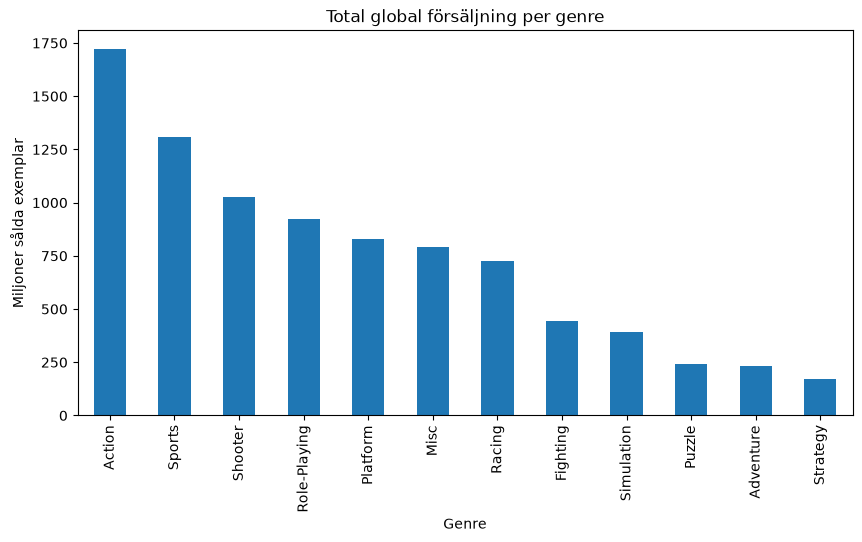

In [20]:
import matplotlib.pyplot as plt

genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

genre_sales.plot(kind='bar', figsize=(10, 5))
plt.title('Total global försäljning per genre')
plt.ylabel('Miljoner sålda exemplar')
plt.xlabel('Genre')
plt.show()

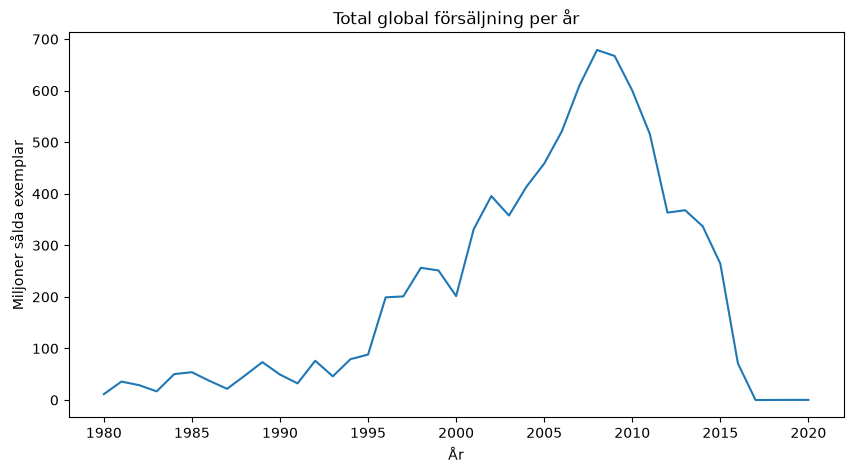

In [21]:
year_sales = df_clean.groupby('Year')['Global_Sales'].sum()

year_sales.plot(kind='line', figsize=(10, 5))
plt.title('Total global försäljning per år')
plt.ylabel('Miljoner sålda exemplar')
plt.xlabel('År')
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

le_platform = LabelEncoder()
le_genre = LabelEncoder()

df_model['Platform_encoded'] = le_platform.fit_transform(df_model['Platform'])
df_model['Genre_encoded'] = le_genre.fit_transform(df_model['Genre'])

df_model[['Platform', 'Platform_encoded', 'Genre', 'Genre_encoded']].head()

,Platform,Platform_encoded,Genre,Genre_encoded
0,Wii,26,Sports,10
1,NES,11,Platform,4
2,Wii,26,Racing,6
3,Wii,26,Sports,10
4,GB,5,Role-Playing,7


In [23]:
X = df_model[['Platform_encoded', 'Genre_encoded', 'Year']]
y = df_model['Global_Sales']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Träningsdata: {len(X_train)} rader")
print(f"Testdata: {len(X_test)} rader")

Träningsdata: 13032 rader
Testdata: 3259 rader


In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Modellen är tränad!")

Modellen är tränad!


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} miljoner")
print(f"R² score: {r2:.2f}")

Mean Absolute Error: 0.61 miljoner
R² score: -0.06


In [27]:
df_clean['Global_Sales'].describe()

count    16291.000000
mean         0.540910
std          1.567345
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: Global_Sales, dtype: float64

In [28]:
model = RandomForestRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} miljoner")
print(f"R²: {r2:.2f}")

MAE: 0.59 miljoner
R²: 0.00


In [29]:
import pickle

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/le_platform.pkl', 'wb') as f:
    pickle.dump(le_platform, f)

with open('../models/le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)

print("Modell och encoders sparade!")

Modell och encoders sparade!
